## Bayesian prior exploration

This notebook outlines our exploratory analysis to guide our choice of priors for our pandemic intensity and duration distributions. Both will be determined jointly based on their implied distribution for pandemic mortality.

In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import seaborn as sns
import scipy
from tqdm.auto import tqdm

In [2]:
az.style.use("arviz-darkgrid")
cores = 4

### Duration modeling

We've chosen to model pandemic duration as following a lognormal distribution, i.e., $ln(d) \sim N(\mu, \sigma)$.

One implication of this modeling decision is that duration is rather fat-tailed. This captures plausible outcomes such as HIV/AIDS, but fitting to the data leads to even 200 year+ pandemics receiving substantial probability density. Sensible treatment therefore requires truncation.

Bayesian modeling in general lends itself well to encoding information about the ranges of values that we find plausible. Unfortunately, however, the lognomal distribution doesn't allow for straightforward control of the mean duration, as it is a function both of the $\mu$ and $\sigma$ ($E[d] = e^{\mu + \sigma^2 / 2}$).

I will nonetheless proceed with the lognormal distribution as it is the distribution we've chosen, but we could consider whether alternative distributions might better reflect our views without crude ex post truncation.

In [3]:
# Load actual duration data
final_allrisk_ds = pd.read_csv("../../data/clean/final_allrisk_ds.csv")
duration_data = final_allrisk_ds['duration']

For now we consider two different priors for the lognormal distribution:
1. **The common reference prior $\pi(\mu, \sigma) \propto \frac{1}{\sigma}$.**
	
	The prior is improper but provides a proper posterior with at least two observations.
2. **The normal-inverse gamma (NIG) distribution.**
	
	NIG is a conjugate prior for the normal distribution, and as such yields an analytically integral posterior when combined with the lognormal log likelihood functions. The NIG distribution is characterized by the following distributional assumptions:
	
	$\sigma^2 \sim Inverse-gamma(\alpha_0, \beta_0)$, and $\mu | \sigma^2 \sim N(\mu_0, \frac{\sigma^2}{\kappa_0})$
	
	The parameters have the following interpretations:
	- $\mu_0$ is our prior guess for the log mean.
	- $\kappa_0$ is our prior confidence in $\mu$. It plays the same role as the square root of the sample size in determining the standard error in frequentist analysis.
	- $\alpha_0$ is a shape parameter that controls the 'peakiness' of the distribution. Higher $\alpha_0$ means more peaky.
	- $\beta_0$ is a scale parameter controlling the scale of the distribution.

The reference prior was chosen as it represents the minimal possible assumption of prior information. The NIG prior was chosen because it yields an analytically tractable posterior. We can easily choose other priors.

Below we visualize the NIG prior under different parameter assumptions. The common reference prior has a non-finite integral, thus a meaningful density function cannot be visualized.

In [4]:
class LogNormalBayesianUpdater:
    def __init__(self, prior_type='reference', mu0=0, kappa0=0.01, alpha0=1.1, beta0=1):
        """
        Initialize the Bayesian updater.
        
        prior_type: 'reference' or 'NIG' (Normal-Inverse-Gamma)
        mu0, kappa0, alpha0, beta0: Hyperparameters for NIG prior
        """
        if prior_type not in ['reference', 'NIG']:
            raise ValueError("prior_type must be either 'reference' or 'NIG'")
        self.prior_type = prior_type
        self.mu0 = mu0
        self.kappa0 = kappa0
        self.alpha0 = alpha0
        self.beta0 = beta0

    def update(self, X):
        """
        Update posterior given observed data X (lognormal data).
        """
        self.X = X
        self.Y = np.log(X)  # work on log scale
        self.n = len(X)
        self.y_bar = np.mean(self.Y)
        self.S = np.sum((self.Y - self.y_bar) ** 2)

        if self.prior_type == 'NIG':
            self.kappa_n = self.kappa0 + self.n
            self.mu_n = (self.kappa0 * self.mu0 + self.n * self.y_bar) / self.kappa_n
            self.alpha_n = self.alpha0 + self.n / 2
            self.beta_n = (self.beta0 + 0.5 * self.S + 
                           0.5 * self.kappa0 * self.n * (self.y_bar - self.mu0)**2 / self.kappa_n)
        elif self.prior_type == 'reference':
            self.kappa_n = self.n
            self.mu_n = self.y_bar
            self.alpha_n = (self.n - 1) / 2
            self.beta_n = self.S / 2
    
    def sample_prior(self, n_samples=1000):
        """
        Sample (mu, sigma) from the prior distribution.
        
        Parameters
        ----------
        n_samples : int
            Number of samples to draw from the prior distribution
            
        Returns
        -------
        tuple
            (mu_samples, sigma_samples) drawn from the prior distribution.
            Returns None, None if using reference prior since it is improper.
        """
        if self.prior_type == 'reference':
            print("Reference prior is improper (only defined up to proportionality). Skipping prior samples.")
            return None, None
            
        sigma2_samples = scipy.stats.invgamma.rvs(a=self.alpha0, scale=self.beta0, size=n_samples)
        sigma_samples = np.sqrt(sigma2_samples)
        mu_samples = scipy.stats.norm.rvs(loc=self.mu0, scale=np.sqrt(sigma2_samples / self.kappa0))
        
        return mu_samples, sigma_samples

    def sample_posterior(self, n_samples=1000):
        """
        Sample (mu, sigma) from the posterior distribution.
        """
        sigma2_samples = scipy.stats.invgamma.rvs(a=self.alpha_n, scale=self.beta_n, size=n_samples)
        sigma_samples = np.sqrt(sigma2_samples)
        mu_samples = scipy.stats.norm.rvs(loc=self.mu_n, scale=np.sqrt(sigma2_samples / self.kappa_n))
        return mu_samples, sigma_samples
   
    def get_prior_grid(self, mu_range=None, sigma_range=None, n_points=100):
        """
        Calculate the analytical prior probability density function on a grid.
        
        Parameters
        ----------
        mu_range : tuple, optional
            Range of mu values (min, max). If None, determined automatically.
        sigma_range : tuple, optional
            Range of sigma values (min, max). If None, determined automatically.
        n_points : int, optional
            Number of points to use in each dimension, by default 50
            
        Returns
        -------
        dict
            Dictionary containing grid points and density values:
            - 'mu_grid': 2D array of mu values
            - 'sigma_grid': 2D array of sigma values 
            - 'density': 2D array of density values
        """
        if self.prior_type == 'reference':
            print("Reference prior is improper. Cannot calculate analytical PDF.")
            return None
        
        # Generate grid of points
        if mu_range is None: # Three expected stds around mean
            mu_range = (self.mu0 - 3 * np.sqrt(self.beta0 / ((self.alpha0 - 1) * self.kappa0)), # 
                        self.mu0 + 3 * np.sqrt(self.beta0 / ((self.alpha0 - 1) * self.kappa0)))
        
        if sigma_range is None:
            mode_sigma = np.sqrt(self.beta0 / (self.alpha0 + 1 + 0.5))  # Mode of inverse gamma
            sigma_range = (mode_sigma / 3, mode_sigma * 3)
        
        mu_grid = np.linspace(*mu_range, n_points)
        sigma_grid = np.linspace(*sigma_range, n_points)
        MU, SIGMA = np.meshgrid(mu_grid, sigma_grid)
        
        # Calculate prior density
        SIGMA2 = SIGMA ** 2
        prior_density = np.zeros_like(MU)
        
        # p(mu, sigma²) = p(mu|sigma²) * p(sigma²)
        # p(mu|sigma²) = Normal(mu0, sigma²/kappa0)
        # p(sigma²) = InvGamma(alpha0, beta0)
        for i in range(n_points):
            for j in range(n_points):
                mu_density = scipy.stats.norm.pdf(MU[i,j], loc=self.mu0, scale=np.sqrt(SIGMA2[i,j] / self.kappa0))
                sigma2_density = scipy.stats.invgamma.pdf(SIGMA2[i,j], a=self.alpha0, scale=self.beta0)
                prior_density[i,j] = mu_density * sigma2_density
                
        return pd.DataFrame({
            'mu': MU.flatten(),
            'sigma': SIGMA.flatten(),
            'density': prior_density.flatten()
        })

    def get_posterior_grid(self, mu_range=None, sigma_range=None, n_points=100):
        """
        Calculate the analytical posterior probability density function on a grid.
        
        Parameters
        ----------
        mu_range : tuple, optional
            Range of mu values (min, max). If None, determined automatically.
        sigma_range : tuple, optional
            Range of sigma values (min, max). If None, determined automatically.
        n_points : int, optional
            Number of points to use in each dimension, by default 50
            
        Returns
        -------
        dict
            Dictionary containing grid points and density values:
            - 'mu_grid': 2D array of mu values
            - 'sigma_grid': 2D array of sigma values
            - 'density': 2D array of density values
        """
        # Generate grid of points
        if mu_range is None:
            mu_range = (self.mu_n - 3 * np.sqrt(self.beta_n / ((self.alpha_n - 1) * self.kappa_n)), 
                        self.mu_n + 3 * np.sqrt(self.beta_n / ((self.alpha_n - 1) * self.kappa_n)))
        
        if sigma_range is None:
            mode_sigma = np.sqrt(self.beta_n / (self.alpha_n + 1 + 0.5))  # Mode of inverse gamma
            sigma_range = (mode_sigma / 3, mode_sigma * 3)
        
        mu_grid = np.linspace(mu_range[0], mu_range[1], n_points)
        sigma_grid = np.linspace(sigma_range[0], sigma_range[1], n_points)
        MU, SIGMA = np.meshgrid(mu_grid, sigma_grid)
        
        # Calculate posterior density
        SIGMA2 = SIGMA**2
        posterior_density = np.zeros_like(MU)
        
        # p(mu, sigma²|data) = p(mu|sigma², data) * p(sigma²|data)
        # p(mu|sigma², data) = Normal(mu_n, sigma²/kappa_n)
        # p(sigma²|data) = InvGamma(alpha_n, beta_n)
        for i in range(n_points):
            for j in range(n_points):
                mu_density = scipy.stats.norm.pdf(MU[i,j], loc=self.mu_n, scale=np.sqrt(SIGMA2[i,j] / self.kappa_n))
                sigma2_density = scipy.stats.invgamma.pdf(SIGMA2[i,j], a=self.alpha_n, scale=self.beta_n)
                posterior_density[i,j] = mu_density * sigma2_density
                
        return pd.DataFrame({
            'mu': MU.flatten(),
            'sigma': SIGMA.flatten(),
            'density': posterior_density.flatten()
        })
    

### Calibrate prior distribution

We want to pick priors that we think capture our reasonable expectations for pandemic duration.

The CEPI expert survey asked the following question:

> We assume that for the majority of pandemics, 75% of the mortality, financial harm, and school closures from pandemics peaks within the first two years after the outbreak occurred We use this to specify how long to calculate costs (e.g., investments in surge response) and benefits. Is this:
>	- Too high 
>	- About right
>	- Too low
>
>	Comments:___________

Three experts say too high, two say about right, and one who says too low while clarifying that it depends on whether vaccines/therapeutics are available.

Based on these responses, I propose starting by calibrating a prior that in expectation is four years long, puts 1/6 of the model prior probability < 2 years, 1/3 probability 2-3 years, and 1/2 probability more than three years.

In [9]:
# Calibrate central moments for NIG prior
def calibrate_lognormal_interval(mean_target, lower, upper, interval_prob):
    """Calibrate (mu, sigma) so that E[X]=mean_target and P(lower<=X<=upper)=interval_prob."""
    def eq(vars):
        mu, sigma = vars
        m = np.exp(mu + sigma**2/2) - mean_target
        cdf = scipy.stats.norm.cdf
        p = cdf((np.log(upper)-mu)/sigma) - cdf((np.log(lower)-mu)/sigma) - interval_prob
        return [m, p]
    
    mu_init, sigma_init = np.log(mean_target), 0.3
    return scipy.optimize.fsolve(eq, [mu_init, sigma_init])

def calibrate_lognormal_three_bins(mean_target, t1, t2, p_lt_t1, p_between, max_iter=1000):
    """Calibrate (mu, sigma) under three bin constraints and report residuals."""
    from scipy.optimize import least_squares
    
    def residuals(vars):
        mu, sigma = vars
        mean_res = np.exp(mu + sigma**2/2) - mean_target
        cdf1 = scipy.stats.norm.cdf((np.log(t1)-mu)/sigma)
        cdf2 = scipy.stats.norm.cdf((np.log(t2)-mu)/sigma)
        p1_res = cdf1 - p_lt_t1
        p2_res = (cdf2 - cdf1) - p_between
        return np.array([mean_res, p1_res, p2_res])
    
    mu0, sigma0 = np.log(mean_target), 0.4
    sol = least_squares(residuals, (mu0, sigma0), bounds=([-10,1e-3],[10,5]), max_nfev=max_iter)
    
    if not sol.success:
        raise RuntimeError("Calibration failed: "+sol.message)
    
    resid_vec = residuals(sol.x)
    resid_norm = float(np.linalg.norm(resid_vec))
    return float(sol.x[0]), float(sol.x[1]), resid_vec, resid_norm

def calibrate_nig_prior(mu_target, sigma_target, *, kappa0=1, alpha0=2):
    """Return (mu0, kappa0, alpha0, beta0) so that E[μ]=mu_target and E[σ²]=sigma_target²."""
    mu0 = mu_target
    beta0 = (alpha0 - 1) * sigma_target ** 2  # sets E[σ²]=sigma_target²
    return mu0, kappa0, alpha0, beta0

# -----------------------------------------------------------------------------
# Plot survival envelope induced by an NIG prior
# -----------------------------------------------------------------------------

def plot_survival_from_nig(mu0, kappa0, alpha0, beta0, *,
                           t_max=20, n_points=10000, n_draws=10000, cred=0.90,
                           ax=None, label="NIG prior", color="C0"):
    """Visualise the distribution of survival curves implied by an NIG prior.

    Draws `n_draws` samples of (mu, sigma²) ~ NIG and plots the median survival
    function plus a central credible band of width `cred` (default 90%).
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(6,4))

    # sample sigma² then mu
    sigma2 = scipy.stats.invgamma.rvs(alpha0, scale=beta0, size=n_draws)
    sigma = np.sqrt(sigma2)
    mu = scipy.stats.norm.rvs(loc=mu0, scale=np.sqrt(sigma2/kappa0))

    t = np.linspace(1e-6, t_max, n_points)
    surv_samples = scipy.stats.lognorm.sf(t[:, None], sigma, scale=np.exp(mu))  # shape [T, draws]
    print(surv_samples.shape)

    median = np.median(surv_samples, axis=1)
    lower  = np.quantile(surv_samples, (1-cred)/2, axis=1)
    upper  = np.quantile(surv_samples, 1-(1-cred)/2, axis=1)

    ax.plot(t, lower, upper, color=color, linestyle='--', label=f"{int(cred*100)}% band")
    ax.plot(t, median, color=color, lw=2, label=f"Median")
    
    ax.set_title("Duration distribution prior")
    ax.set_xlabel("Years")
    ax.set_ylabel("Survival S(t)")
    ax.set_xlim(0, t_max)
    ax.grid(True, which="both", ls=":", lw=0.6)
    ax.legend()
    return ax

LogNormal (mean≈3.43, P[2≤X≤3]=1/3): mu=1.1350, sigma=0.4392
Residual:[-0.00396983 -0.0094763  -0.02351626]
(10000, 10000)


<Axes: title={'center': 'Duration distribution prior'}, xlabel='Years', ylabel='Survival S(t)'>

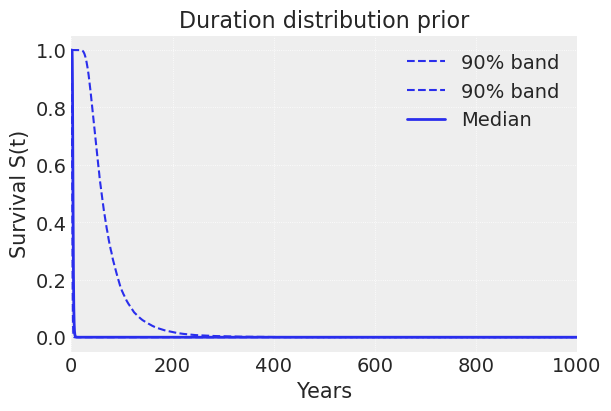

In [10]:
mu_target, sigma_target, resid_vec, resid_norm = calibrate_lognormal_three_bins(mean_target=3.43, t1=2, t2=3, p_lt_t1=1/6, p_between=1/3)
print(f"LogNormal (mean≈3.43, P[2≤X≤3]=1/3): mu={mu_target:.4f}, sigma={sigma_target:.4f}")
print(f"Residual:{resid_vec}")

mu0, kappa0, alpha0, beta0 = calibrate_nig_prior(mu_target, sigma_target,
                                                 kappa0=1, # Minimal information assumption
                                                 alpha0=2 # Minimal information assumption
                                                 )

plot_survival_from_nig(mu0, kappa0, alpha0, beta0, t_max=1000)

The 90% confidence band is much too high. Let's increase kappa0 until we get a more reasonable prior.

LogNormal (mean≈3.43, P[2≤X≤3]=1/3): mu=1.1887, sigma=0.2960


<Axes: title={'center': 'Duration distribution prior'}, xlabel='Years', ylabel='Survival S(t)'>

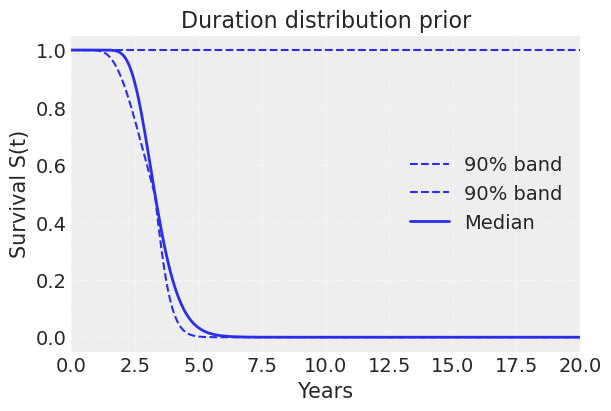

In [30]:
mu_target, sigma_target = calibrate_lognormal_interval(mean_target=3.43, lower=2, upper=3, interval_prob=1/3)
print(f"LogNormal (mean≈3.43, P[2≤X≤3]=1/3): mu={mu_target:.4f}, sigma={sigma_target:.4f}")

mu0, kappa0, alpha0, beta0 = calibrate_nig_prior(mu_target, sigma_target,
                                                 kappa0=10000, # Minimal information assumption
                                                 alpha0=2 # Minimal information assumption
                                                 )

plot_survival_from_nig(mu0, kappa0, alpha0, beta0)